# Anwiaso East — Full LULC Pipeline (Python / Colab, no GEE browser)

**What this notebook does differently from the browser JS version:**
- Connects to GEE via the Python API — no browser Code Editor needed
- Pulls Sentinel-1 + Sentinel-2 features and samples them *directly* in Python
- Trains a `sklearn` Random Forest and **saves the model to Drive**
- On future runs you can skip straight to *Cell 7 — Load saved model* and reuse it

**Run order:**
1. Install & imports
2. Authenticate GEE
3. Config
4. Build feature stack (runs on GEE servers)
5. Define training polygons & sample features
6. Train RF → save model
7. (Skip to here on future runs) Load saved model
8. Accuracy assessment
9. Feature importance
10. Predict & export full classified map
11. Visualise

In [ ]:
# CELL 1 — Install
!pip install earthengine-api geemap rasterio geopandas fiona contextily -q

In [3]:
# CELL 2 — Imports
import ee
import geemap
import os
import json
import joblib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
from skimage.morphology import disk
from skimage.filters.rank import majority as majority_filter_sk
from scipy.ndimage import label as nd_label, distance_transform_edt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    cohen_kappa_score, accuracy_score, f1_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance

from google.colab import drive

print('✅ Imports OK')

✅ Imports OK


In [4]:
# CELL 3 — Authenticate & initialise GEE
#
# NEW SESSION  → uncomment ee.Authenticate(), run the cell, visit the URL,
#                paste the code, press Enter. Then comment it out again.
# SAME SESSION → leave ee.Authenticate() commented out; just run ee.Initialize().
#
# A "new session" = you just opened Colab, or the runtime was reset/disconnected.

ee.Authenticate(auth_mode='notebook')   # ← uncomment for a new session only

ee.Initialize(project='data-pipeline-1-464218')

print('✅ GEE initialised')
print(f'   Project : data-pipeline-1-464218')

✅ GEE initialised
   Project : data-pipeline-1-464218


In [13]:
# # CELL 4 — CONFIG  +  Drive API client
# #
# # drive.mount() is bypassed entirely — it uses an ephemeral FUSE system that
# # is broken in this environment.  Instead we reuse the OAuth credentials that
# # ee.Authenticate() already saved and access Drive through the REST API.
# # Files are downloaded to /content/ for processing and uploaded back when done.

# import io
# from google.oauth2.credentials import Credentials
# from google.auth.transport.requests import Request
# from googleapiclient.discovery import build
# from googleapiclient.http import MediaIoBaseDownload, MediaFileUpload

# # ── Load credentials saved by ee.Authenticate(auth_mode='notebook') ──────────
# # Those credentials include the Drive scope, so no extra auth step is needed.
# _creds_path = os.path.expanduser('~/.config/earthengine/credentials')
# with open(_creds_path) as _f:
#     _creds_data = json.load(_f)

# _drive_creds = Credentials(
#     token         = None,
#     refresh_token = _creds_data['refresh_token'],
#     token_uri     = 'https://oauth2.googleapis.com/token',
#     client_id     = _creds_data['client_id'],
#     client_secret = _creds_data['client_secret'],
#     scopes        = ['https://www.googleapis.com/auth/drive']
# )
# _drive_creds.refresh(Request())
# _drive_svc = build('drive', 'v3', credentials=_drive_creds)
# print('✅ Drive API client ready (no mount needed)')

# # ── Local working directory (files downloaded here for processing) ─────────────
# LOCAL_DIR  = Path('/content/Forest_LULC_Classification')
# OUTPUT_DIR = LOCAL_DIR / 'RF_Results'
# LOCAL_DIR.mkdir(exist_ok=True)
# OUTPUT_DIR.mkdir(exist_ok=True)

# DRIVE_FOLDER = 'Forest_LULC_Classification'   # folder name in your Google Drive

In [15]:
# CELL 4 — CONFIG  +  Drive API client

import io
from google.oauth2.credentials import Credentials
from google.auth.transport.requests import Request
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaFileUpload

_creds_path = os.path.expanduser('~/.config/earthengine/credentials')
with open(_creds_path) as _f:
    _creds_data = json.load(_f)

_drive_creds = Credentials(
    token=None, refresh_token=_creds_data['refresh_token'],
    token_uri='https://oauth2.googleapis.com/token',
    client_id=_creds_data['client_id'], client_secret=_creds_data['client_secret'],
    scopes=['https://www.googleapis.com/auth/drive']
)
_drive_creds.refresh(Request())
_drive_svc = build('drive', 'v3', credentials=_drive_creds)
print('✅ Drive API client ready')

LOCAL_DIR  = Path('/content/Forest_LULC_Classification')
OUTPUT_DIR = LOCAL_DIR / 'RF_Results'
LOCAL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
DRIVE_FOLDER = 'Forest_LULC_Classification'


def _get_folder_id(folder_name):
    res = _drive_svc.files().list(
        q=f"name='{folder_name}' and mimeType='application/vnd.google-apps.folder' and trashed=false",
        fields='files(id)'
    ).execute()
    if not res['files']:
        raise FileNotFoundError(f"Drive folder '{folder_name}' not found.")
    return res['files'][0]['id']


def download_from_drive(filename, dest_dir=LOCAL_DIR):
    dest = Path(dest_dir) / filename
    if dest.exists():
        print(f'   Already present locally: {filename}')
        return str(dest)
    folder_id = _get_folder_id(DRIVE_FOLDER)
    res = _drive_svc.files().list(
        q=f"name='{filename}' and '{folder_id}' in parents and trashed=false",
        fields='files(id, name)'
    ).execute()
    if not res['files']:
        raise FileNotFoundError(f"'{filename}' not found in Drive folder '{DRIVE_FOLDER}'.")
    request = _drive_svc.files().get_media(fileId=res['files'][0]['id'])
    with io.FileIO(str(dest), 'wb') as fh:
        dl = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            _, done = dl.next_chunk()
    print(f'   Downloaded from Drive: {filename}')
    return str(dest)


def upload_to_drive(local_path, subfolder=None):
    local_path = Path(local_path)
    parent_id  = _get_folder_id(DRIVE_FOLDER)
    if subfolder:
        res = _drive_svc.files().list(
            q=f"name='{subfolder}' and '{parent_id}' in parents and mimeType='application/vnd.google-apps.folder' and trashed=false",
            fields='files(id)'
        ).execute()
        parent_id = res['files'][0]['id'] if res['files'] else _drive_svc.files().create(
            body={'name': subfolder, 'mimeType': 'application/vnd.google-apps.folder', 'parents': [parent_id]},
            fields='id'
        ).execute()['id']
    existing = _drive_svc.files().list(
        q=f"name='{local_path.name}' and '{parent_id}' in parents and trashed=false", fields='files(id)'
    ).execute()
    media = MediaFileUpload(str(local_path), resumable=True)
    if existing['files']:
        _drive_svc.files().update(fileId=existing['files'][0]['id'], media_body=media).execute()
    else:
        _drive_svc.files().create(
            body={'name': local_path.name, 'parents': [parent_id]}, media_body=media, fields='id'
        ).execute()
    print(f'   Uploaded to Drive: {local_path.name}')


CFG = {
    'gpkg_path':           str(LOCAL_DIR / 'study_area.gpkg'),
    'gpkg_layer':          'study_area',
    'training_gpkg_path':  str(LOCAL_DIR / 'training_dataset.gpkg'),
    'training_gpkg_layer': 'training_dataset',
    'landcover_field':     'landcover',
    'class_name_field':    None,
    'class_colors':        None,

    # ── Dry season only — Nov→Feb gives the cleanest imagery for Ghana ────────
    'start_date':   '2025-11-01',
    'end_date':     '2026-02-28',
    'cloud_thresh': 20,

    'export_folder': DRIVE_FOLDER,
    'export_crs':    'EPSG:32630',
    'export_scale':  10,

    'n_estimators':     100,
    'max_depth':        None,
    'min_samples_leaf': 3,
    'max_features':     'sqrt',
    'class_weight':     'balanced',
    'cv_folds':         3,
    'random_state':     42,

    'sample_scale': 10,
    'train_size':   0.70,
    'val_size':     0.15,
    'test_size':    0.15,

    'band_names': [
        'B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12',
        'NDVI','NDWI','NDRE','EVI','SAVI','NBR','BSI',
        'VV_mean','VH_mean','VV_min','VH_min',
        'VV_max','VH_max','VV_std','VH_std','VH_VV_ratio'
    ],

    'class_names': [],
    'num_classes': 0,
    'model_path':  str(OUTPUT_DIR / 'rf_model.joblib'),
}

print('✅ CONFIG loaded')
print(f'   Dates       : {CFG["start_date"]} → {CFG["end_date"]}  (dry season only)')
print(f'   Output dir  : {OUTPUT_DIR}')

✅ Drive API client ready
✅ CONFIG loaded
   Dates       : 2025-11-01 → 2026-02-28  (dry season only)
   Output dir  : /content/Forest_LULC_Classification/RF_Results


In [16]:
# CELL 5 — All helper & pipeline functions

def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10)).Not()
    return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])


def apply_speckle_filter(image):
    vv = image.select('VV').focal_mean(radius=5, kernelType='square', units='pixels').rename('VV')
    vh = image.select('VH').focal_mean(radius=5, kernelType='square', units='pixels').rename('VH')
    return image.addBands(vv, None, True).addBands(vh, None, True)


def build_features(study_area):
    start = CFG['start_date']
    end   = CFG['end_date']

    s2 = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(study_area)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CFG['cloud_thresh']))
        .map(mask_s2_clouds)
        .median()
        .clip(study_area)
    )

    bands = s2.select(['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12'])
    NDVI  = s2.normalizedDifference(['B8','B4']).rename('NDVI')
    NDWI  = s2.normalizedDifference(['B3','B8']).rename('NDWI')
    NDRE  = s2.normalizedDifference(['B8','B5']).rename('NDRE')
    EVI   = s2.expression(
        '2.5*((NIR-RED)/(NIR+6*RED-7.5*BLUE+1))',
        {'NIR': s2.select('B8'), 'RED': s2.select('B4'), 'BLUE': s2.select('B2')}
    ).rename('EVI')
    SAVI  = s2.expression(
        '1.5*(NIR-RED)/(NIR+RED+0.5)',
        {'NIR': s2.select('B8'), 'RED': s2.select('B4')}
    ).rename('SAVI')
    NBR   = s2.normalizedDifference(['B8','B12']).rename('NBR')
    BSI   = s2.expression(
        '((SWIR+RED)-(NIR+BLUE))/((SWIR+RED)+(NIR+BLUE))',
        {'SWIR': s2.select('B11'), 'RED': s2.select('B4'),
         'NIR':  s2.select('B8'),  'BLUE': s2.select('B2')}
    ).rename('BSI')

    s1 = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(study_area)
        .filterDate(start, end)
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .map(apply_speckle_filter)
    )

    mean    = s1.select(['VV','VH']).mean().rename(['VV_mean','VH_mean'])
    mn      = s1.select(['VV','VH']).min().rename(['VV_min','VH_min'])
    mx      = s1.select(['VV','VH']).max().rename(['VV_max','VH_max'])
    std     = s1.select(['VV','VH']).reduce(ee.Reducer.stdDev()).rename(['VV_std','VH_std'])
    ratio   = mean.select('VH_mean').divide(mean.select('VV_mean')).rename('VH_VV_ratio')
    s1_feat = mean.addBands(mn).addBands(mx).addBands(std).addBands(ratio).clip(study_area)

    combined = (
        bands
        .addBands(NDVI).addBands(NDWI).addBands(NDRE)
        .addBands(EVI).addBands(SAVI).addBands(NBR).addBands(BSI)
        .addBands(s1_feat)
    )
    print('Feature bands:', combined.bandNames().getInfo())
    return combined


def load_study_area_from_gpkg(path, layer=None):
    print(f'Reading GeoPackage: {path}')
    layers = gpd.list_layers(path)
    print(f'   Layers in file: {layers["name"].tolist()}')

    gdf = gpd.read_file(path, layer=layer)
    print(f'   Features read : {len(gdf)}')
    print(f'   Source CRS    : {gdf.crs}')

    if gdf.crs is None:
        raise ValueError('GeoPackage has no CRS defined. Set it in your GIS software first.')
    gdf = gdf.to_crs('EPSG:4326')

    dissolved = gdf.dissolve()
    geom      = dissolved.geometry.iloc[0]
    geojson   = json.loads(gpd.GeoSeries([geom]).to_json())
    ee_geom   = ee.Geometry(geojson['features'][0]['geometry'])

    print(f'   Bounding box  : {geom.bounds}')
    print('✅ Study area loaded from GeoPackage')
    return ee_geom, gdf


def load_training_from_gpkg(path, layer=None, landcover_field='landcover'):
    print(f'Reading training GeoPackage: {path}')
    layers = gpd.list_layers(path)
    print(f'   Layers in file  : {layers["name"].tolist()}')

    gdf = gpd.read_file(path, layer=layer)
    print(f'   Features read   : {len(gdf)}')
    print(f'   Columns         : {list(gdf.columns)}')
    print(f'   Source CRS      : {gdf.crs}')

    if landcover_field not in gdf.columns:
        available = [c for c in gdf.columns if c != 'geometry']
        raise ValueError(
            f"Column '{landcover_field}' not found.\n"
            f"Available columns: {available}\n"
            f"Update 'landcover_field' in CONFIG to match your column name."
        )

    if gdf.crs is None:
        raise ValueError('Training GeoPackage has no CRS. Set it in your GIS software first.')
    gdf = gdf.to_crs('EPSG:4326')

    col = gdf[landcover_field]

    # ── Detect text vs integer column ─────────────────────────────────────────
    if col.dtype == object or str(col.dtype) == 'string':
        # TEXT column — auto-assign integer IDs in alphabetical order
        # Alphabetical keeps the mapping deterministic across runs.
        class_names = sorted(col.unique().tolist())
        name_to_id  = {name: i for i, name in enumerate(class_names)}
        gdf['landcover'] = col.map(name_to_id).astype(int)
        print(f'\n   Text column detected → auto-encoded to integers (alphabetical):')
        for name, i in name_to_id.items():
            print(f'     {i}  →  {name}')
    else:
        # INTEGER column — use as-is; optionally read names from class_name_field
        gdf['landcover'] = col.astype(int)
        unique_ids   = sorted(gdf['landcover'].unique())
        n_classes    = max(unique_ids) + 1
        name_field   = CFG.get('class_name_field')

        if name_field and name_field in gdf.columns:
            id_to_name  = (
                gdf[['landcover', name_field]]
                .drop_duplicates()
                .sort_values('landcover')
                .set_index('landcover')[name_field]
                .to_dict()
            )
            class_names = [id_to_name.get(i, f'Class {i}') for i in range(n_classes)]
            print(f'\n   Integer column — class names from "{name_field}"')
        else:
            class_names = [f'Class {i}' for i in range(n_classes)]
            print(f'\n   Integer column — no class_name_field set, using generic names.')

    n_classes = len(class_names)

    # ── Auto-generate colours if not supplied ─────────────────────────────────
    existing_colors = CFG.get('class_colors')
    if not existing_colors or len(existing_colors) != n_classes:
        class_colors = [mcolors.to_hex(cm.tab10(i % 10)) for i in range(n_classes)]
        print(f'   Auto-generated {n_classes} colours from tab10 palette')
    else:
        class_colors = existing_colors

    # ── Write back into CFG so all downstream cells pick them up ──────────────
    CFG['class_names']  = class_names
    CFG['class_colors'] = class_colors
    CFG['num_classes']  = n_classes

    # ── Print class distribution ──────────────────────────────────────────────
    print('\n   Class distribution:')
    for cls_id, cls_name in enumerate(class_names):
        count = (gdf['landcover'] == cls_id).sum()
        print(f'     {cls_id}  {cls_name:<26}: {count:>4}  {"█" * min(count, 40)}')

    training_ee = geemap.geopandas_to_ee(gdf[['geometry', 'landcover']])
    print(f'\n✅ Training data loaded — {len(gdf)} polygons, {n_classes} classes → ee.FeatureCollection')
    return training_ee, gdf


def absorb_small_patches(arr, mmu_pixels):
    nodata_mask = (arr == 255)
    small_mask  = np.zeros(arr.shape, dtype=bool)

    for cls_val in np.unique(arr[~nodata_mask]):
        labeled, n = nd_label(arr == cls_val)
        for region_id in range(1, n + 1):
            if (labeled == region_id).sum() < mmu_pixels:
                small_mask |= (labeled == region_id)

    pixels_to_fill = small_mask & ~nodata_mask
    if not pixels_to_fill.any():
        print('         No patches below MMU — nothing to absorb')
        return arr

    invalid = small_mask | nodata_mask
    _, nearest_idx = distance_transform_edt(invalid, return_indices=True)

    result     = arr.copy()
    rows, cols = np.where(pixels_to_fill)
    result[rows, cols] = arr[nearest_idx[0][rows, cols], nearest_idx[1][rows, cols]]

    print(f'         Absorbed {pixels_to_fill.sum():,} px ({pixels_to_fill.sum() / arr.size * 100:.2f}% of image) into neighbours')
    return result


def generalise_and_vectorise(pred_map, meta, output_dir, class_names, class_colors,
                              majority_radius, mmu_pixels, simplify_tol):
    transform     = meta['transform']
    crs           = meta['crs']
    pixel_area_m2 = abs(transform.a * transform.e)
    mmu_ha        = mmu_pixels * pixel_area_m2 / 10_000

    print(f'Step 1 — Majority filter  (radius={majority_radius} px)...')
    smoothed = majority_filter_sk(pred_map.astype(np.uint8), disk(majority_radius))
    print(f'         Unique classes after filter: {np.unique(smoothed).tolist()}')

    print(f'Step 2 — MMU absorption  ({mmu_pixels} px = {mmu_ha:.4f} ha)...')
    smoothed = absorb_small_patches(smoothed, mmu_pixels)

    print('Step 3 — Vectorising...')
    valid_mask = (smoothed != 255).astype(np.uint8)
    raw_shapes = list(shapes(smoothed, mask=valid_mask, transform=transform))
    print(f'         Raw patches: {len(raw_shapes):,}')

    records = [{'geometry': shape(geom), 'class_id': int(val)} for geom, val in raw_shapes]
    gdf     = gpd.GeoDataFrame(records, crs=crs)

    print(f'Step 4 — Simplifying geometry  (tolerance={simplify_tol} m)...')
    gdf['geometry'] = gdf.geometry.simplify(tolerance=simplify_tol, preserve_topology=True)

    gdf['class_name']  = gdf['class_id'].apply(lambda i: class_names[i] if i < len(class_names) else 'Unknown')
    gdf['class_color'] = gdf['class_id'].apply(lambda i: class_colors[i] if i < len(class_colors) else '#888888')
    gdf_utm            = gdf.to_crs(CFG['export_crs'])
    gdf['area_ha']     = gdf_utm.geometry.area / 10_000

    print('Step 5 — Dissolving by class...')
    gdf_dissolved = gdf.dissolve(by='class_id', aggfunc={'area_ha': 'sum'}).reset_index()
    gdf_dissolved['class_name']  = gdf_dissolved['class_id'].apply(lambda i: class_names[i] if i < len(class_names) else 'Unknown')
    gdf_dissolved['class_color'] = gdf_dissolved['class_id'].apply(lambda i: class_colors[i] if i < len(class_colors) else '#888888')
    gdf_dissolved['geometry']    = gdf_dissolved.geometry.simplify(tolerance=simplify_tol, preserve_topology=True)

    gpkg_out = str(output_dir / 'lulc_classification.gpkg')
    gdf.to_file(          gpkg_out, layer='lulc_patches',  driver='GPKG')
    gdf_dissolved.to_file(gpkg_out, layer='lulc_by_class', driver='GPKG')

    print(f'\n✅ GeoPackage saved: {gpkg_out}')
    print(f'   lulc_patches   — {len(gdf):,} individual patches')
    print(f'   lulc_by_class  — {len(gdf_dissolved)} class polygons')

    total_ha = gdf_dissolved['area_ha'].sum()
    print(f'\n{"─"*56}')
    print(f'  {"Class":<26}  {"Patches":>7}  {"Area (ha)":>10}  {"% Total":>7}')
    print(f'{"─"*56}')
    for _, row in gdf_dissolved.sort_values('class_id').iterrows():
        pct     = row['area_ha'] / total_ha * 100
        n_patch = (gdf['class_id'] == row['class_id']).sum()
        print(f'  {row["class_name"]:<26}  {n_patch:>7,}  {row["area_ha"]:>10,.1f}  {pct:>6.1f}%  {"█" * int(pct / 2.5)}')
    print(f'{"─"*56}')
    print(f'  {"TOTAL":<26}  {len(gdf):>7,}  {total_ha:>10,.1f}  {"100.0%":>7}')

    return gdf, gdf_dissolved, gpkg_out


print('✅ All functions defined')

✅ All functions defined


In [17]:
# CELL 6 — Download study area GeoPackage from Drive, then build feature stack

download_from_drive('study_area.gpkg')   # → /content/Forest_LULC_Classification/

study_area, study_area_gdf = load_study_area_from_gpkg(
    CFG['gpkg_path'],
    layer=CFG['gpkg_layer']
)

combined_features = build_features(study_area)
print('\n✅ Feature image ready (server-side — nothing downloaded yet)')

   Already present locally: study_area.gpkg
Reading GeoPackage: /content/Forest_LULC_Classification/study_area.gpkg
   Layers in file: ['study_area']
   Features read : 709
   Source CRS    : EPSG:4326
   Bounding box  : (-2.258330348872303, 6.0450453999999985, -2.1089541, 6.3644061999999995)
✅ Study area loaded from GeoPackage
Feature bands: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'NDRE', 'EVI', 'SAVI', 'NBR', 'BSI', 'VV_mean', 'VH_mean', 'VV_min', 'VH_min', 'VV_max', 'VH_max', 'VV_std', 'VH_std', 'VH_VV_ratio']

✅ Feature image ready (server-side — nothing downloaded yet)


In [ ]:
# Run if  download_from_drive throws error due to landcover field being null
import os
os.remove('/content/Forest_LULC_Classification/training_dataset.gpkg')
download_from_drive('training_dataset.gpkg')


   Downloaded from Drive: training_dataset.gpkg


'/content/Forest_LULC_Classification/training_dataset.gpkg'

In [18]:
# CELL 7 — Download training GeoPackage from Drive, then load polygons

download_from_drive('training_dataset.gpkg')   # → /content/Forest_LULC_Classification/

training_data, training_gdf = load_training_from_gpkg(
    CFG['training_gpkg_path'],
    layer=CFG['training_gpkg_layer'],
    landcover_field=CFG['landcover_field']
)

print('EE feature count:', training_data.size().getInfo())

   Already present locally: training_dataset.gpkg
Reading training GeoPackage: /content/Forest_LULC_Classification/training_dataset.gpkg
   Layers in file  : ['training_dataset']
   Features read   : 709
   Columns         : ['id_0', 'planting_type', 'landcover', 'geometry']
   Source CRS      : EPSG:4326

   Text column detected → auto-encoded to integers (alphabetical):
     0  →  Cedrella
     1  →  Cocoa
     2  →  Degraded Forest
     3  →  Dense Forest
     4  →  Farms
     5  →  Galamsey
     6  →  Invasives
     7  →  Natural Forest
     8  →  Open Areas
     9  →  Road buffer
     10  →  Swamp
   Auto-generated 11 colours from tab10 palette

   Class distribution:
     0  Cedrella                  :    1  █
     1  Cocoa                     :   51  ████████████████████████████████████████
     2  Degraded Forest           :   15  ███████████████
     3  Dense Forest              :   91  ████████████████████████████████████████
     4  Farms                     :  178  ████████

In [33]:
# CELL 9 — Sample pixel values & export to Drive as CSV

import time

print('Sampling feature values at training polygons...')
samples_ee = combined_features.sampleRegions(
    collection = training_data,
    properties = ['landcover'],
    scale      = CFG['sample_scale'],
    tileScale  = 4,
    geometries = False
)

task = ee.batch.Export.table.toDrive(
    collection=samples_ee, description='training_samples',
    folder=DRIVE_FOLDER, fileNamePrefix='training_samples', fileFormat='CSV'
)
task.start()
print('Export task submitted — waiting...')

while task.active():
    print(f'   Status: {task.status()["state"]}    ', end='\r')
    time.sleep(15)

final_state = task.status()['state']
print(f'\nTask finished: {final_state}')
if final_state != 'COMPLETED':
    raise RuntimeError(f'Export failed: {final_state}')

for fname in ['training_samples.csv', 'class_mapping.json']:
    p = LOCAL_DIR / fname
    if p.exists():
        p.unlink()

csv_path = download_from_drive('training_samples.csv')
df = pd.read_csv(csv_path)

# ── Build class mapping directly from the GeoPackage file ────────────────────
# This is the ONLY reliable source — CFG['class_names'] can be corrupted
# if Cell 10 ran before this cell in the same session.
_gdf_raw = gpd.read_file(CFG['training_gpkg_path'], layer=CFG['training_gpkg_layer'])
_col     = _gdf_raw[CFG['landcover_field']]
if _col.dtype == object or str(_col.dtype) == 'string':
    _class_names = sorted(_col.dropna().unique().tolist())
else:
    raise ValueError('landcover_field is not a text column — check your GeoPackage.')

mapping = {str(i): name for i, name in enumerate(_class_names)}
mapping_path = str(LOCAL_DIR / 'class_mapping.json')
with open(mapping_path, 'w') as f:
    json.dump(mapping, f, indent=2)
upload_to_drive(mapping_path)

print(f'\nSamples : {len(df):,}')
print(f'Mapping : {mapping}')
print('\nClass distribution (raw CSV):')
for i_str, name in sorted(mapping.items(), key=lambda x: int(x[0])):
    count = (df['landcover'] == int(i_str)).sum()
    print(f'  {i_str:>2}  {name:<26}: {count:,}')

Sampling feature values at training polygons...
Export task submitted — waiting...
   Status: RUNNING    
Task finished: COMPLETED
   Downloaded from Drive: training_samples.csv
   Uploaded to Drive: class_mapping.json

Samples : 633,790
Mapping : {'0': 'Cedrella', '1': 'Cocoa', '2': 'Degraded Forest', '3': 'Dense Forest', '4': 'Farms', '5': 'Galamsey', '6': 'Invasives', '7': 'Natural Forest', '8': 'Open Areas', '9': 'Road buffer', '10': 'Swamp'}

Class distribution (raw CSV):
   0  Cedrella                  : 1
   1  Cocoa                     : 17,543
   2  Degraded Forest           : 22,342
   3  Dense Forest              : 142,818
   4  Farms                     : 181,191
   5  Galamsey                  : 5,133
   6  Invasives                 : 93,975
   7  Natural Forest            : 20,190
   8  Open Areas                : 140,706
   9  Road buffer               : 2,807
  10  Swamp                     : 7,084


In [34]:
# CELL 10 — Prepare X / y arrays
#
# Loads the class mapping saved by Cell 9 — never reads CFG['class_names']
# directly so the ID→name mapping is always consistent with the CSV.

mapping_path = LOCAL_DIR / 'class_mapping.json'
if not mapping_path.exists():
    download_from_drive('class_mapping.json')

with open(mapping_path) as f:
    raw_mapping = json.load(f)

id_to_name = {int(k): v for k, v in raw_mapping.items()}
print('Class mapping from saved file:')
for i, name in sorted(id_to_name.items()):
    print(f'  {i:>2}  {name}')

# ── Feature matrix ────────────────────────────────────────────────────────────
band_names = CFG['band_names']
available_bands = [b for b in band_names if b in df.columns]
if len(available_bands) != len(band_names):
    print(f'⚠️  Missing bands: {set(band_names)-set(available_bands)}')
    band_names = available_bands

X_raw = df[band_names].values.astype(np.float32)
y_raw = df['landcover'].values.astype(np.int32)
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

# ── Drop classes with fewer than 2 samples ────────────────────────────────────
counts   = {cls: int((y_raw == cls).sum()) for cls in np.unique(y_raw)}
drop_ids = [cls for cls, n in counts.items() if n < 2]
if drop_ids:
    print(f'\n⚠️  Dropping (< 2 samples): {[id_to_name.get(i, f"id={i}") for i in drop_ids]}')
    keep  = np.isin(y_raw, drop_ids, invert=True)
    X_raw, y_raw = X_raw[keep], y_raw[keep]

# ── Remap to contiguous 0-N ───────────────────────────────────────────────────
remaining     = sorted(np.unique(y_raw).tolist())
id_remap      = {old: new for new, old in enumerate(remaining)}
y_raw         = np.array([id_remap[i] for i in y_raw], dtype=np.int32)

new_names     = [id_to_name.get(i, f'Class {i}') for i in remaining]
new_colors    = [mcolors.to_hex(cm.tab10(j % 10)) for j in range(len(new_names))]

CFG['class_names']  = new_names
CFG['class_colors'] = new_colors
CFG['num_classes']  = len(new_names)

print(f'\nClasses after filtering ({len(new_names)}):')
for j, name in enumerate(new_names):
    print(f'  {j:>2}  {name:<26}: {int((y_raw==j).sum()):,}')

X, y = X_raw, y_raw
print(f'\nX : {X.shape}')

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=(CFG['val_size']+CFG['test_size']),
    stratify=y, random_state=CFG['random_state']
)
val_ratio = CFG['val_size'] / (CFG['val_size'] + CFG['test_size'])
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=(1-val_ratio),
    stratify=y_tmp, random_state=CFG['random_state']
)
print(f'Train {len(X_tr):,} | Val {len(X_val):,} | Test {len(X_test):,}')

Class mapping from saved file:
   0  Cedrella
   1  Cocoa
   2  Degraded Forest
   3  Dense Forest
   4  Farms
   5  Galamsey
   6  Invasives
   7  Natural Forest
   8  Open Areas
   9  Road buffer
  10  Swamp

⚠️  Dropping (< 2 samples): ['Cedrella']

Classes after filtering (10):
   0  Cocoa                     : 17,543
   1  Degraded Forest           : 22,342
   2  Dense Forest              : 142,818
   3  Farms                     : 181,191
   4  Galamsey                  : 5,133
   5  Invasives                 : 93,975
   6  Natural Forest            : 20,190
   7  Open Areas                : 140,706
   8  Road buffer               : 2,807
   9  Swamp                     : 7,084

X : (633789, 26)
Train 443,652 | Val 95,068 | Test 95,069


In [35]:
# CELL 11 — Train Random Forest & save to Drive

print(f'Training set size : {len(X_tr):,} samples × {X_tr.shape[1]} bands')

# ── Stratified subsample — equal quota per class ──────────────────────────────
# Random subsampling leaves rare classes under-represented even with
# class_weight='balanced'. Equal quota ensures every class gets fair coverage.
MAX_PER_CLASS = 3_000   # ≤ 3k per class → at most 30k total for 10 classes

X_parts, y_parts = [], []
rng = np.random.default_rng(42)

for cls_id in range(CFG['num_classes']):
    mask = (y_tr == cls_id)
    Xc, yc = X_tr[mask], y_tr[mask]
    if len(Xc) == 0:
        continue
    n   = min(len(Xc), MAX_PER_CLASS)
    idx = rng.choice(len(Xc), n, replace=False)
    X_parts.append(Xc[idx])
    y_parts.append(yc[idx])

X_tr_fit = np.vstack(X_parts)
y_tr_fit = np.concatenate(y_parts)
print(f'Stratified subsample : {len(X_tr_fit):,} samples  ({MAX_PER_CLASS} per class max)')

rf = RandomForestClassifier(
    n_estimators     = CFG['n_estimators'],
    max_depth        = CFG['max_depth'],
    min_samples_leaf = CFG['min_samples_leaf'],
    max_features     = CFG['max_features'],
    class_weight     = CFG['class_weight'],
    oob_score        = True,
    n_jobs           = -1,
    random_state     = CFG['random_state']
)

print(f'Running {CFG["cv_folds"]}-fold cross-validation...')
cv        = StratifiedKFold(n_splits=CFG['cv_folds'], shuffle=True, random_state=CFG['random_state'])
cv_scores = cross_val_score(rf, X_tr_fit, y_tr_fit, cv=cv, scoring='accuracy', n_jobs=-1)
print(f'CV Accuracy : {cv_scores.mean()*100:.2f}% (± {cv_scores.std()*100:.2f}%)')

rf.fit(X_tr_fit, y_tr_fit)
print(f'OOB Score   : {rf.oob_score_*100:.2f}%')

joblib.dump(rf, CFG['model_path'])
upload_to_drive(CFG['model_path'], subfolder='RF_Results')
print(f'\n✅ Model saved and uploaded to Drive')

Training set size : 443,652 samples × 26 bands
Stratified subsample : 28,965 samples  (3000 per class max)
Running 3-fold cross-validation...
CV Accuracy : 52.85% (± 0.41%)
OOB Score   : 53.98%
   Uploaded to Drive: rf_model.joblib

✅ Model saved and uploaded to Drive


In [ ]:
# CELL 12 — Load saved model (run this instead of Cell 11 on future sessions)
#
# Prerequisites for a fresh Colab session:
#   - Run Cells 1-4 (install, imports, auth, config)
#   - Run this cell
#   - Then continue from Cell 13 onward

rf = joblib.load(CFG['model_path'])
print(f'✅ Model loaded from {CFG["model_path"]}')
print(f'   Trees      : {rf.n_estimators}')
print(f'   OOB Score  : {rf.oob_score_*100:.2f}%')

# Also reload training split if you want to re-run evaluation
# (only needed if you skipped Cells 9-10)
if 'X_test' not in dir():
    print('\n⚠️  X_test not in memory. Run Cells 9-10 to reload samples, or skip to Cell 15 for prediction.')

Overall Accuracy : 43.65%
Cohen's Kappa    : 0.3343

                 precision    recall  f1-score   support

          Cocoa      0.181     0.623     0.281      2631
Degraded Forest      0.273     0.653     0.385      3352
   Dense Forest      0.620     0.514     0.562     21423
          Farms      0.601     0.313     0.412     27179
       Galamsey      0.393     0.808     0.529       770
      Invasives      0.379     0.317     0.345     14097
 Natural Forest      0.181     0.494     0.265      3028
     Open Areas      0.598     0.501     0.545     21106
    Road buffer      0.125     0.705     0.213       421
          Swamp      0.157     0.652     0.253      1062

       accuracy                          0.436     95069
      macro avg      0.351     0.558     0.379     95069
   weighted avg      0.526     0.436     0.454     95069



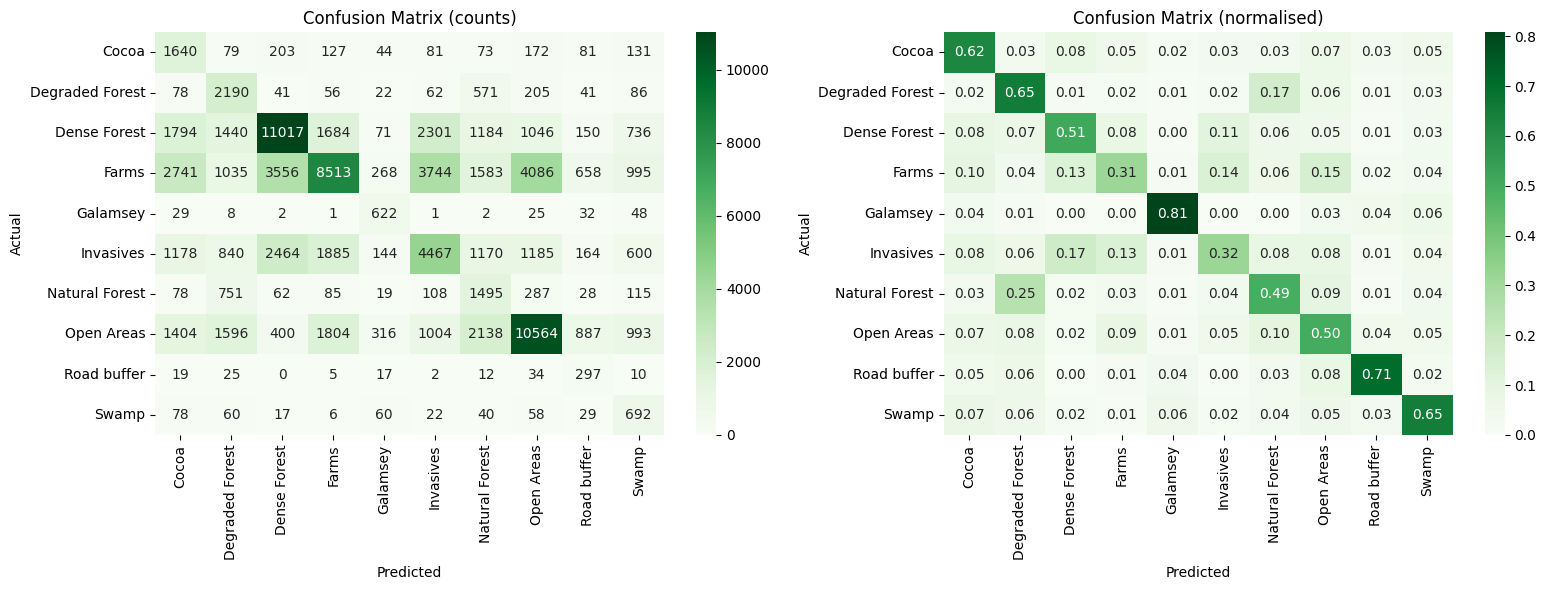

In [36]:
# CELL 13 — Accuracy assessment

y_pred = rf.predict(X_test)
oa     = accuracy_score(y_test, y_pred)
kappa  = cohen_kappa_score(y_test, y_pred)

print(f'Overall Accuracy : {oa*100:.2f}%')
print(f"Cohen's Kappa    : {kappa:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CFG['class_names'], digits=3))

# Confusion matrix
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
short   = [n.split('/')[0].strip() for n in CFG['class_names']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm,      annot=True, fmt='d',    cmap='Greens', xticklabels=short, yticklabels=short, ax=axes[0])
sns.heatmap(cm_norm, annot=True, fmt='.2f',  cmap='Greens', xticklabels=short, yticklabels=short, ax=axes[1])
axes[0].set(title='Confusion Matrix (counts)',     ylabel='Actual', xlabel='Predicted')
axes[1].set(title='Confusion Matrix (normalised)', ylabel='Actual', xlabel='Predicted')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'rf_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

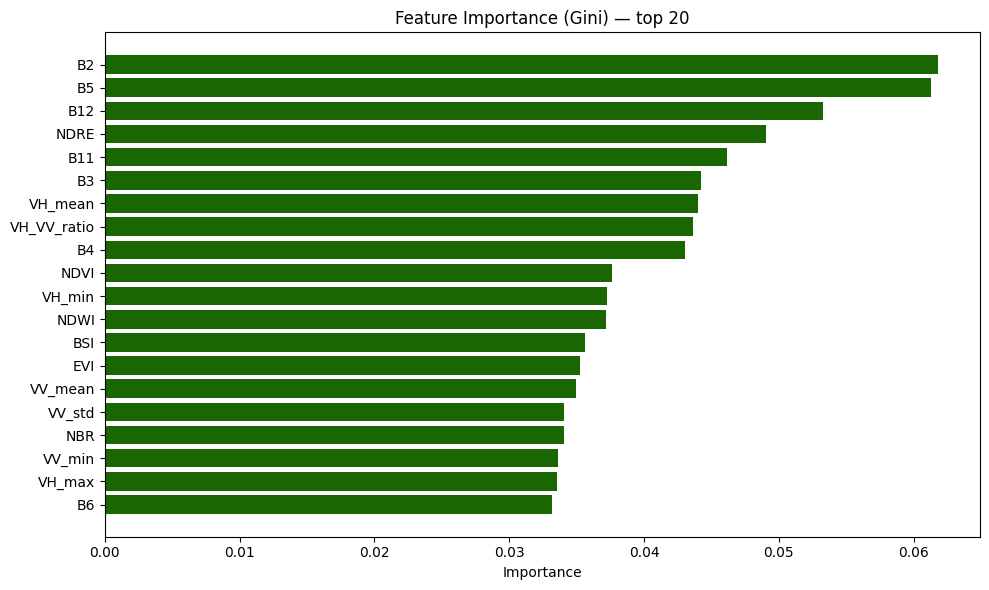

Top 10:
   1. B2              ██████████████████████████████ 0.0618
   2. B5              █████████████████████████████ 0.0613
   3. B12             █████████████████████████ 0.0533
   4. NDRE            ███████████████████████ 0.0490
   5. B11             ██████████████████████ 0.0462
   6. B3              █████████████████████ 0.0442
   7. VH_mean         █████████████████████ 0.0440
   8. VH_VV_ratio     █████████████████████ 0.0436
   9. B4              ████████████████████ 0.0430
  10. NDVI            ██████████████████ 0.0376


In [37]:
# CELL 14 — Feature importance

gini      = rf.feature_importances_
top_idx   = np.argsort(gini)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.barh([band_names[i] for i in reversed(top_idx)], gini[list(reversed(top_idx))], color='#1a6600')
plt.title('Feature Importance (Gini) — top 20')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'rf_feature_importance.png'), dpi=150)
plt.show()

print('Top 10:')
for rank, i in enumerate(top_idx[:10], 1):
    bar = '█' * int(gini[i] / gini[top_idx[0]] * 30)
    print(f'  {rank:>2}. {band_names[i]:<15} {bar} {gini[i]:.4f}')

In [42]:
# CELL 15 — Export feature stack from GEE → Drive

import time

task = ee.batch.Export.image.toDrive(
    image          = combined_features.toFloat(),   # cast all bands to Float32
    description    = 'Anwiaso_S1_S2_Features_2024',
    folder         = CFG['export_folder'],
    fileNamePrefix = 'anwiaso_s1_s2_features_2024',
    region         = study_area,
    scale          = CFG['export_scale'],
    crs            = CFG['export_crs'],
    maxPixels      = 1e13,
    fileFormat     = 'GeoTIFF'
)
task.start()
print('✅ Export task submitted — waiting...')

while task.active():
    print(f'   {task.status()["state"]}    ', end='\r')
    time.sleep(20)

state = task.status()['state']
print(f'\nFinal state: {state}')
if state == 'COMPLETED':
    print('✅ Export done — run Cell 16.')
else:
    print(f'❌ Failed: {task.status().get("error_message")}')

✅ Export task submitted — waiting...
   RUNNING    
Final state: COMPLETED
✅ Export done — run Cell 16.


In [43]:
print(task.status())


{'state': 'COMPLETED', 'description': 'Anwiaso_S1_S2_Features_2024', 'priority': 100, 'creation_timestamp_ms': 1779987273596, 'update_timestamp_ms': 1779988260074, 'start_timestamp_ms': 1779987276042, 'task_type': 'EXPORT_IMAGE', 'destination_uris': ['https://drive.google.com/#folders/1UmZejaZF1UtWzY2qLg6A2F8_XjT3iuwV'], 'attempt': 1, 'batch_eecu_usage_seconds': 3897.287841796875, 'id': 'DEQVNWOQYOGETR34VY5LBXYG', 'name': 'projects/data-pipeline-1-464218/operations/DEQVNWOQYOGETR34VY5LBXYG'}


In [44]:
# CELL 16 — Download exported GeoTIFF from Drive & run full prediction
#
# Run this after the GEE export task from Cell 15 shows COMPLETED.

FEATURES_FILENAME = 'anwiaso_s1_s2_features_2024.tif'
features_path = download_from_drive(FEATURES_FILENAME)

print(f'Loading: {features_path}')
with rasterio.open(features_path) as src:
    arr  = src.read().astype(np.float32)
    meta = src.meta.copy()

print(f'Shape: {arr.shape}')
arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

n_bands, H, W = arr.shape
flat = arr.reshape(n_bands, -1).T

CHUNK     = 500_000
pred_flat = np.zeros(H * W, dtype=np.uint8)
prob_flat = np.zeros((H * W, len(CFG['class_names'])), dtype=np.float32)

for start in range(0, len(flat), CHUNK):
    end   = min(start + CHUNK, len(flat))
    chunk = np.nan_to_num(flat[start:end], nan=0.0, posinf=0.0, neginf=0.0)
    pred_flat[start:end] = rf.predict(chunk)
    prob_flat[start:end] = rf.predict_proba(chunk)
    print(f'  {end/len(flat)*100:.0f}%', end='\r')

pred_map = pred_flat.reshape(H, W)
prob_map = prob_flat.T.reshape(len(CFG['class_names']), H, W)
print('\n✅ Full image predicted')

# Save classified GeoTIFF locally then upload to Drive
out_meta = meta.copy()
out_meta.update({'count': 1, 'dtype': 'uint8', 'nodata': 255})
map_out  = str(OUTPUT_DIR / 'lulc_classification_2024.tif')
with rasterio.open(map_out, 'w', **out_meta) as dst:
    dst.write(pred_map[np.newaxis])
upload_to_drive(map_out, subfolder='RF_Results')

# Save uncertainty map locally then upload to Drive
probs_safe = np.clip(prob_map, 1e-10, 1.0)
entropy    = -np.sum(probs_safe * np.log(probs_safe), axis=0)
unc_meta   = meta.copy()
unc_meta.update({'count': 1, 'dtype': 'float32', 'nodata': -9999})
unc_out    = str(OUTPUT_DIR / 'lulc_uncertainty_2024.tif')
with rasterio.open(unc_out, 'w', **unc_meta) as dst:
    dst.write(entropy[np.newaxis].astype(np.float32))
upload_to_drive(unc_out, subfolder='RF_Results')

print('✅ Rasters saved locally and uploaded to Drive/RF_Results/')

   Downloaded from Drive: anwiaso_s1_s2_features_2024.tif
Loading: /content/Forest_LULC_Classification/anwiaso_s1_s2_features_2024.tif
Shape: (26, 3533, 1651)
  100%
✅ Full image predicted
   Uploaded to Drive: lulc_classification_2024.tif
   Uploaded to Drive: lulc_uncertainty_2024.tif
✅ Rasters saved locally and uploaded to Drive/RF_Results/


In [47]:
# CELL 17 — Generalise, vectorise & upload to Drive

MAJORITY_RADIUS = 2
MMU_PIXELS      = 100
SIMPLIFY_TOL    = 10

gdf_patches, gdf_classes, gpkg_path = generalise_and_vectorise(
    pred_map, meta, OUTPUT_DIR,
    CFG['class_names'], CFG['class_colors'],
    majority_radius=MAJORITY_RADIUS,
    mmu_pixels=MMU_PIXELS,
    simplify_tol=SIMPLIFY_TOL
)

# Upload GeoPackage to Drive
upload_to_drive(gpkg_path, subfolder='RF_Results')
print('✅ GeoPackage uploaded → Drive/Forest_LULC_Classification/RF_Results/lulc_classification.gpkg')

Step 1 — Majority filter  (radius=2 px)...
         Unique classes after filter: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Step 2 — MMU absorption  (100 px = 1.0000 ha)...
         Absorbed 170,507 px (2.92% of image) into neighbours
Step 3 — Vectorising...
         Raw patches: 597
Step 4 — Simplifying geometry  (tolerance=10 m)...
Step 5 — Dissolving by class...

✅ GeoPackage saved: /content/Forest_LULC_Classification/RF_Results/lulc_classification.gpkg
   lulc_patches   — 597 individual patches
   lulc_by_class  — 10 class polygons

────────────────────────────────────────────────────────
  Class                       Patches   Area (ha)  % Total
────────────────────────────────────────────────────────
  Cocoa                            37    52,930.3    90.7%  ████████████████████████████████████
  Degraded Forest                  75       483.0     0.8%  
  Dense Forest                     45     1,373.4     2.4%  
  Farms                           107       935.5     1.6%  
  Galamsey      

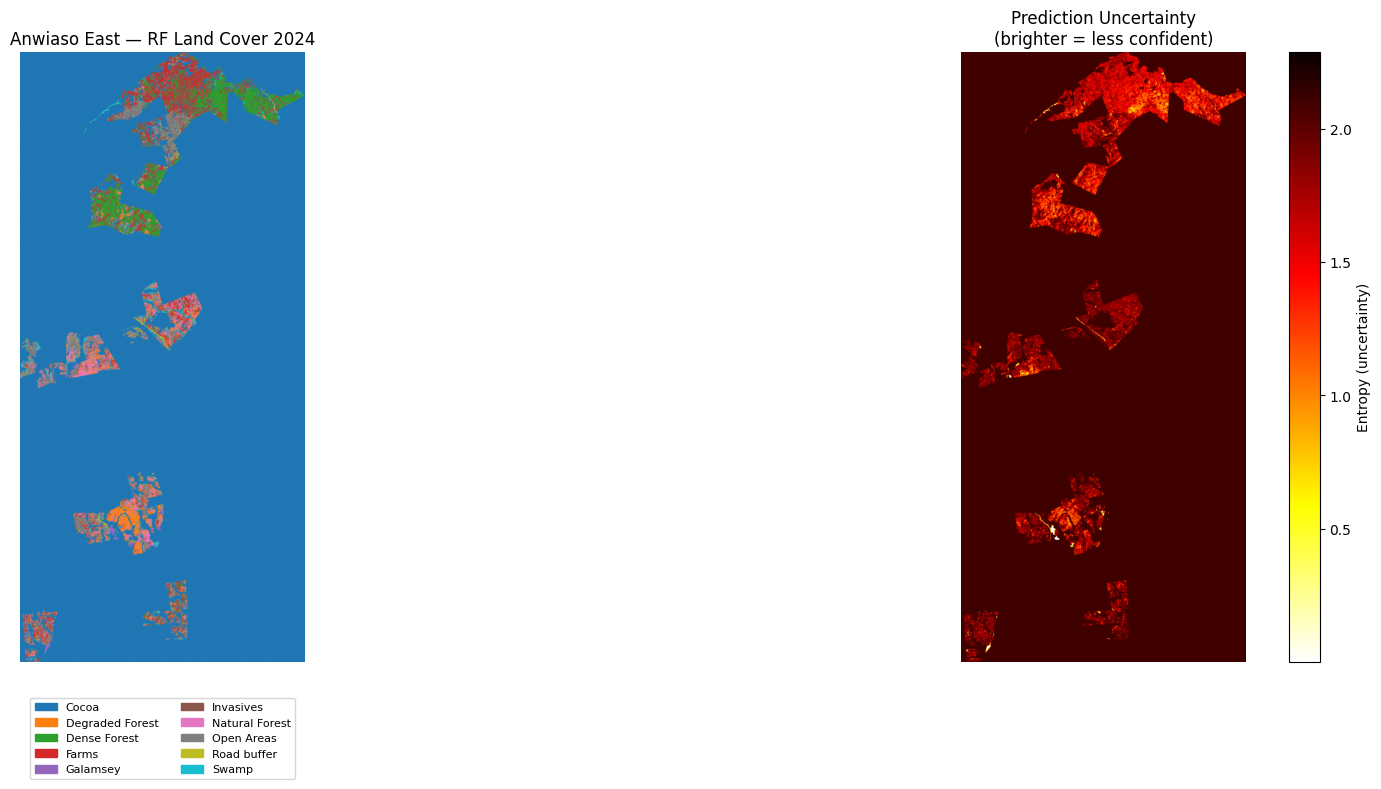


╔══════════════════════════════════════════════╗
║  PIPELINE COMPLETE                           ║
║  Saved to Drive → RF_Results/                ║
║    *.tif  — classified map + uncertainty     ║
║    *.png  — visuals                          ║
║    rf_model.joblib — reload with joblib      ║
╚══════════════════════════════════════════════╝


In [46]:
# CELL 17 — Visualise classification + uncertainty

cmap    = mcolors.ListedColormap(CFG['class_colors'])
patches = [
    mpatches.Patch(color=CFG['class_colors'][i], label=CFG['class_names'][i])
    for i in range(len(CFG['class_names']))
]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(pred_map, cmap=cmap, vmin=0, vmax=len(CFG['class_names'])-1)
axes[0].legend(handles=patches, bbox_to_anchor=(0.5,-0.05), loc='upper center', ncol=2, fontsize=8)
axes[0].set_title('Anwiaso East — RF Land Cover 2024')
axes[0].axis('off')

unc_plot = axes[1].imshow(entropy, cmap='hot_r')
plt.colorbar(unc_plot, ax=axes[1], fraction=0.046, pad=0.04, label='Entropy (uncertainty)')
axes[1].set_title('Prediction Uncertainty\n(brighter = less confident)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'anwiaso_rf_classification_2024.png'), dpi=200, bbox_inches='tight')
plt.show()

print(f'\n╔══════════════════════════════════════════════╗')
print(f'║  PIPELINE COMPLETE                           ║')
print(f'║  Saved to Drive → RF_Results/                ║')
print(f'║    *.tif  — classified map + uncertainty     ║')
print(f'║    *.png  — visuals                          ║')
print(f'║    rf_model.joblib — reload with joblib      ║')
print(f'╚══════════════════════════════════════════════╝')